In [40]:
# ============================================================
# 1. IMPORTS
# ============================================================

import sys
import importlib
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [41]:
# ============================================================
# 2. PROJECT PATH
# ============================================================

project_root = Path(r"C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg")

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.data_pipeline

importlib.reload(src.data_pipeline)

from src.data_pipeline import ModelDatasetBuilder

In [43]:
# ============================================================
# 3. LOAD DATASET
# ============================================================

db_path = project_root / "NordPoool" / "data" / "thesis_database.db"

builder = ModelDatasetBuilder(db_path)

df = builder.build_price_dataset(
    zones="NO1",
    start_date="2020-01-01",
    end_date="2020-12-31",
    add_time_features=False,
    lags=None,
    target_horizon=None,
    include_volumes=False,
    dropna=False
)

df.head()

,price_id,zone_id,delivery_day,hour,price_value
datetime,,,,,
2020-01-01 00:00:00,32,12,2020-01-01,1,31.77
2020-01-01 01:00:00,52,12,2020-01-01,2,31.57
2020-01-01 02:00:00,72,12,2020-01-01,3,31.28
2020-01-01 03:00:00,92,12,2020-01-01,4,30.72
2020-01-01 04:00:00,112,12,2020-01-01,5,30.27


In [44]:
# # ============================================================
# # 4. CREATE TEMPORAL SERIES
# # ============================================================

ts = df["price_value"].asfreq("h")

print("Length:", ts.shape)
print("Duplicates:", ts.index.duplicated().sum())
print("Missing:", ts.isna().sum())
print("Start:", ts.index.min())
print("End:", ts.index.max())

# ============================================================
# 4. CREATE TEMPORAL SERIES AND EXOG VARIABLES
# ============================================================

# df_sarimax = df[
#     [
#         "price_value",
#         "buy_volume_value",
#         "sell_volume_value"
#     ]
# ].asfreq("h").dropna()

# ts = df_sarimax["price_value"]

# exog = df_sarimax[
#     [
#         "buy_volume_value",
#         "sell_volume_value"
#     ]
# ]

# print("Length:", ts.shape)
# print("Duplicates:", ts.index.duplicated().sum())
# print("Missing price:", ts.isna().sum())
# print("Missing exog:", exog.isna().sum())
# print("Start:", ts.index.min())
# print("End:", ts.index.max())

Length: (8761,)
Duplicates: 0
Missing: 0
Start: 2020-01-01 00:00:00
End: 2020-12-31 00:00:00


**Train real model**

In [47]:
# Use only 2020
ts_model = ts["2020-01-01":"2020-12-31"]

# Train/test split for one-week short-term evaluation
train = ts_model["2020-01-01":"2020-11-30 23:00:00"]
test = ts_model["2020-12-01":"2020-12-01 23:00:00"]

# ============================================================
# 5. TRAIN / TEST SPLIT
# ============================================================

# ts_model = ts["2020-01-01":"2020-12-31"]
# exog_model = exog["2020-01-01":"2020-12-31"]

# train = ts_model["2020-01-01":"2020-11-30 23:00:00"]
# test = ts_model["2020-12-01":"2020-12-01 23:00:00"]

# exog_train = exog_model.loc[train.index]
# exog_test = exog_model.loc[test.index]

# print("Train:", train.shape)
# print("Test:", test.shape)
# print("Exog train:", exog_train.shape)
# print("Exog test:", exog_test.shape)

In [48]:
# # Train ARIMA model
model = ARIMA(train, order=(3, 0, 3))
model_fit = model.fit()

print(model_fit.summary())

# ============================================================
# 6. TRAIN SARIMAX MODEL
# ============================================================

# model = SARIMAX(
#     train,
#     exog=exog_train,
#     order=(3, 0, 3),
#     enforce_stationarity=False,
#     enforce_invertibility=False
# )

# model_fit = model.fit(disp=False)

# print(model_fit.summary())

c:\Users\HUGO\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:            price_value   No. Observations:                 8040
Model:                 ARIMA(3, 0, 3)   Log Likelihood              -11737.622
Date:                Tue, 05 May 2026   AIC                          23491.243
Time:                        18:03:09   BIC                          23547.181
Sample:                    01-01-2020   HQIC                         23510.385
                         - 11-30-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         17.9081      7.182      2.493      0.013       3.832      31.985
ar.L1          2.0241      0.008    257.853      0.000       2.009       2.040
ar.L2         -1.3289      0.017    -80.350      0.0

In [49]:
history = list(train)
predictions = []

# Rolling one-step ahead forecast
for t in range(len(test)):
    model = ARIMA(history, order=(3, 0, 3))
    model_fit = model.fit()

    yhat = model_fit.forecast(steps=1)[0]
    predictions.append(yhat)

    # Add real observation to history
    history.append(test.iloc[t])
    
# # Fast forecast: fit once and forecast the whole test period
# forecast = model_fit.forecast(steps=len(test))

# pred_series = pd.Series(forecast.values, index=test.index)
# predictions = pred_series.values

c:\Users\HUGO\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\HUGO\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\HUGO\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\HUGO\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimizat

Ejecution was working almost 17 minutes.

In [51]:
# Evaluate model
mae = mean_absolute_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))
r2 = r2_score(test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.5069724231311425
RMSE: 0.6759119114662213
R2: 0.7583113774145673


In [52]:
pred_series = pd.Series(predictions, index=test.index)

# Define threshold (top 2%)
threshold = test.quantile(0.98)

# Filter peak periods
peak_real = test[test > threshold]
peak_pred = pred_series[test > threshold]


mae_peaks = mean_absolute_error(peak_real, peak_pred)

print("MAE Peaks:", mae_peaks)

MAE Peaks: 1.052433654576344


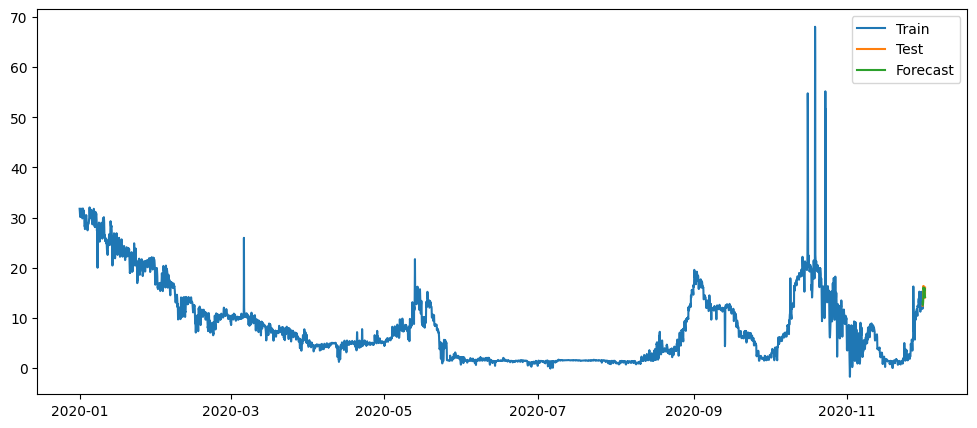

In [53]:
# Plot results
plt.figure(figsize=(12,5))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(test.index, predictions, label="Forecast")

plt.legend()
plt.show()

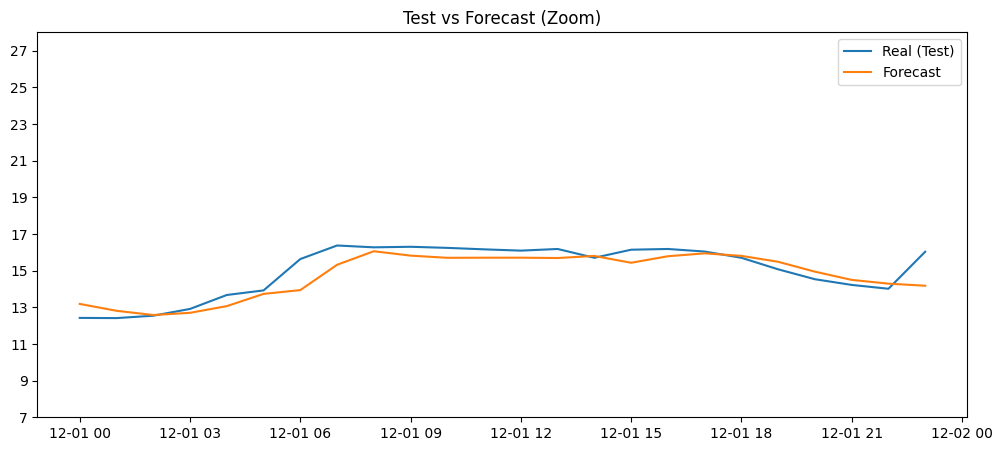

In [54]:
plt.figure(figsize=(12,5))

plt.plot(test.index, test, label="Real (Test)")
plt.plot(test.index, predictions, label="Forecast")

plt.ylim(7, 28)
plt.yticks(range(7, 29, 2))

plt.legend()
plt.title("Test vs Forecast (Zoom)")
plt.show()

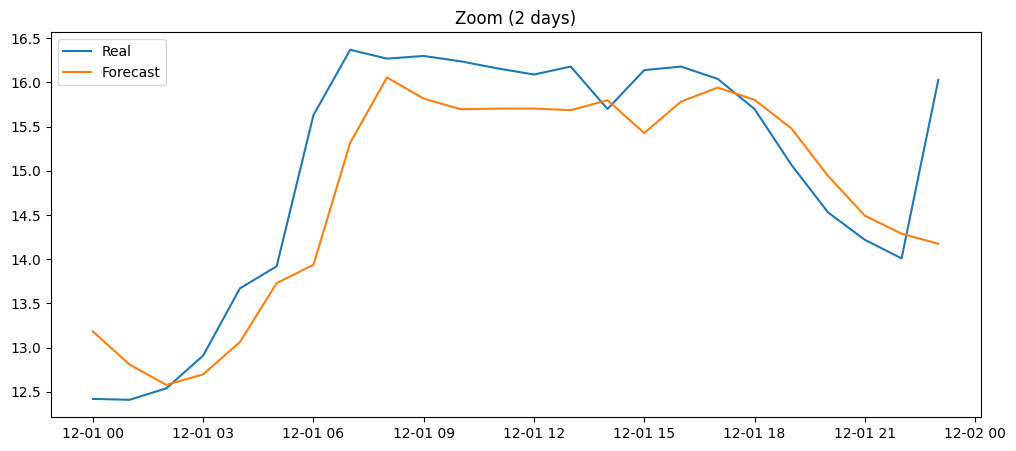

In [55]:
# Select a smaller window
zoom_test = test["2020-12-01":"2020-12-02"]
zoom_pred = predictions[:len(zoom_test)]

plt.figure(figsize=(12,5))

plt.plot(zoom_test.index, zoom_test, label="Real")
plt.plot(zoom_test.index, zoom_pred, label="Forecast")

plt.legend()
plt.title("Zoom (2 days)")
plt.show()

In [24]:
import numpy as np

# Define range of lags to test (in hours)
lags = range(-5, 6)

# Compute correlation for each lag
corrs = [test.corr(pred_series.shift(lag)) for lag in lags]

# Find best lag
best_lag = lags[np.argmax(corrs)]

print("Best lag:", best_lag)

Best lag: -5
